In [2]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

data = pd.read_csv('car_data.csv')


In [3]:
corr = data.corr(numeric_only=True)

print(corr)

                  Year  Age_Years  No_of_Owners  KM_Driven  Price_USD
Year          1.000000  -1.000000     -0.609118  -0.859823   0.628846
Age_Years    -1.000000   1.000000      0.609118   0.859823  -0.628846
No_of_Owners -0.609118   0.609118      1.000000   0.529652  -0.410349
KM_Driven    -0.859823   0.859823      0.529652   1.000000  -0.572720
Price_USD     0.628846  -0.628846     -0.410349  -0.572720   1.000000


In [5]:
X = data[["Brand","Age_Years", "Model", "Car_Type","Transmission","Fuel_Type","No_of_Owners", "KM_Driven"]]
y = data["Price_USD"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

categorical_cols = [
    "Brand",
    "Model",
    "Car_Type",
    "Transmission",
    "Fuel_Type"
]
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

# Polynomial Regression Pipeline
model = Pipeline([
    ("preprocessor", preprocessor),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison.head(10))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)
r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)


      Actual     Predicted
7940    7760  15012.399778
1162   32140  24624.149882
582     9570  22083.844520
4081   10500   9331.018657
8412   21330  19601.558087
8730   14600  17694.149233
5936   16990  18521.267128
8283   16520  18270.078603
3706   21090  22978.553700
4071   30510  22431.731368
RMSE: 8055.982556495835
Mean Absolute Error: 5650.964674072947
R-squared: 0.43676285307576257


In [6]:
joblib.dump(model, "car_price_pipeline.pkl")

['car_price_pipeline.pkl']

In [7]:
model = joblib.load("car_price_pipeline.pkl")

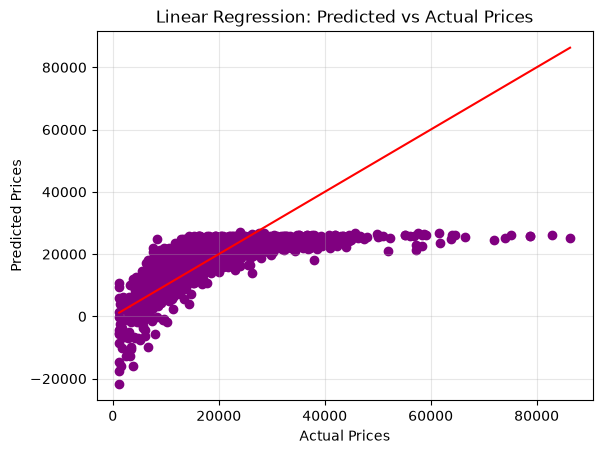

In [30]:
plt.scatter(y_test, y_pred, color='purple', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', label='Perfect Prediction')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Linear Regression: Predicted vs Actual Prices')
plt.grid(alpha=0.3)
plt.show()

In [35]:
user_input = pd.DataFrame({
    "Brand": ["Ford"],
    "Model": ["Mustang"],
    "Car_Type": ["Sedan"],
    "Year": [2022],
    "Age_Years": [2],
    "Transmission": ["Automatic"],
    "Fuel_Type": ["Petrol"],
    "No_of_Owners": [1],
    "KM_Driven": [25000]
})

prediction = model.predict(user_input)

print(prediction[0])

23450.620437156416
